# PPO (RL) in Smart Farm use case

Running the notebook will produce one run of 100 episodes of the RL. To produce more (independent) runs, change the `start_args` and `SEED` below and re-run the notebook.

Only the `10steps` and `reward_shaping_5` configs are currently used (the others were used only for preliminary experimentation and thus are commented out in this notebook).


In [ ]:
!ls -l  # check that we are in the correct directory

In [2]:
import subprocess
import os

SEED = 0

def run(args, repeats=100, start=1):
    print(args)
    for repeat in range(repeats):
        print(f"  Run #{repeat + start}/{repeats + start - 1}")
        run = ["python", "main.py", *args, "-s", str(repeat + start + SEED), "-e", str(repeat + start)]
        if repeat % 25 == 0:
            run.append("--animation")
        
        # disable TF errors
        env = dict(os.environ, TF_CPP_MIN_LOG_LEVEL="3")

        result = subprocess.run(run, capture_output=True, env=env)
        stdout = result.stdout.decode("utf-8")
        stderr = result.stderr.decode("utf-8")

        damage = stdout.partition("damage: ")[2].partition("\n")[0]
        print(f"    Damage: {damage}")

        #print(stdout.partition("Simulation done\n")[2])
        # print(stdout)
        if stderr:
            print(stderr)

In [3]:
common_args = ["farm/configs/default.yaml", "farm/configs/config_no_battery.yaml", "farm/configs/no_battery_rl.yaml"]
end_args = ["farm/configs/no_battery_rl_rs.yaml"]

SEED = 0
start_args = common_args + ["farm/configs/rl1.yaml"]

# SEED = 10
# start_args = common_args + ["farm/configs/rl2.yaml"]

# SEED = 20
# start_args = common_args + ["farm/configs/rl3.yaml"]

In [4]:
# run(start_args + ["configs/ppo.yaml"] + end_args)

In [5]:
run(start_args + ["farm/configs/ppo.yaml", "configs/10steps.yaml"] + end_args)

['farm/configs/default.yaml', 'farm/configs/config_no_battery.yaml', 'farm/configs/no_battery_rl.yaml', 'farm/configs/ppo.yaml', 'configs/10steps.yaml', 'farm/configs/no_battery_rl_rs.yaml', '../configs/deepnote_03rl3.yaml']
  Run #1/100
    Damage: 203
  Run #2/100
    Damage: 293
  Run #3/100
    Damage: 308
  Run #4/100
    Damage: 308
  Run #5/100
    Damage: 308
  Run #6/100
    Damage: 273
  Run #7/100
    Damage: 240
  Run #8/100
    Damage: 292
  Run #9/100
    Damage: 254
  Run #10/100
    Damage: 273
  Run #11/100
    Damage: 245
  Run #12/100
    Damage: 245
  Run #13/100
    Damage: 271
  Run #14/100
    Damage: 273
  Run #15/100
    Damage: 269
  Run #16/100
    Damage: 305
  Run #17/100
    Damage: 310
  Run #18/100
    Damage: 298
  Run #19/100
    Damage: 295
  Run #20/100
    Damage: 286
  Run #21/100
    Damage: 282
  Run #22/100
    Damage: 272
  Run #23/100
    Damage: 251
  Run #24/100
    Damage: 308
  Run #25/100
    Damage: 319
  Run #26/100
    Damage: 292
  Ru

In [6]:
# run(start_args + ["configs/ppo.yaml", "configs/reward_shaping.yaml"] + end_args)

In [7]:
# run(start_args + ["configs/ppo.yaml", "configs/reward_shaping_4.yaml"] + end_args)

In [8]:
# run(start_args + ["configs/ppo.yaml", "configs/10steps.yaml", "configs/reward_shaping.yaml"] + end_args)

In [9]:
# run(start_args + ["configs/ppo.yaml", "configs/10steps.yaml", "configs/reward_shaping_4.yaml"] + end_args)

In [10]:
# run(start_args + ["configs/ppo.yaml", "configs/reward_shaping_5.yaml"] + end_args)

In [11]:
run(start_args + ["farm/configs/ppo.yaml", "configs/10steps.yaml", "farm/configs/reward_shaping_5.yaml"] + end_args)

['farm/configs/default.yaml', 'farm/configs/config_no_battery.yaml', 'farm/configs/no_battery_rl.yaml', 'farm/configs/ppo.yaml', 'configs/10steps.yaml', 'farm/configs/reward_shaping_5.yaml', 'farm/configs/no_battery_rl_rs.yaml', '../configs/deepnote_03rl3.yaml']
  Run #1/100
    Damage: 203
  Run #2/100
    Damage: 311
  Run #3/100
    Damage: 272
  Run #4/100
    Damage: 219
  Run #5/100
    Damage: 253
  Run #6/100
    Damage: 199
  Run #7/100
    Damage: 254
  Run #8/100
    Damage: 225
  Run #9/100
    Damage: 269
  Run #10/100
    Damage: 198
  Run #11/100
    Damage: 196
  Run #12/100
    Damage: 234
  Run #13/100
    Damage: 253
  Run #14/100
    Damage: 251
  Run #15/100
    Damage: 235
  Run #16/100
    Damage: 171
  Run #17/100
    Damage: 216
  Run #18/100
    Damage: 278
  Run #19/100
    Damage: 207
  Run #20/100
    Damage: 235
  Run #21/100
    Damage: 215
  Run #22/100
    Damage: 213
  Run #23/100
    Damage: 201
  Run #24/100
    Damage: 207
  Run #25/100
    Damage: 

## Results - Damage over time

In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import TABLEAU_COLORS


def plot_rl_training(*folders: list[Path], pattern="*.csv", suptitle=""):
    fig, ax = plt.subplots(1, 1, sharex=True, figsize=(10, 5))

    for folder, color in zip(folders, TABLEAU_COLORS):
        folder = Path(folder)
        files = sorted(folder.glob(pattern))
        print(folder, len(files), "files found")
        last_rows = []
        for episode, file in enumerate(files, start=1):
            try:
                # print("Reading", file)
                data = pd.read_csv(file)
                last_row = data.iloc[-1]
                # last_row.name = file.name
                last_row.name = episode
                last_rows.append(last_row)
            except pd.errors.EmptyDataError:
                print("Skipping empty file", file)
            except IndexError:
                print("Index error in file", file)
        df = pd.concat(last_rows, axis=1).T

        # damage
        df["damage"].plot(ax=ax, color=color, alpha=0.5, linestyle='--')
        # average damage
        # avg_damage = df["damage"].mean()
        # avg_series = pd.Series([avg_damage] * len(df), index=df.index)
        avg_series = df["damage"].rolling(window=10).mean()
        avg_series.plot(ax=ax, color=color, linewidth=1)
        print(f"Average damage of last 10 episodes: {avg_series.iloc[-1]}")
        
        df.to_csv(folder.parent / f"{folder.name}.csv", index=False)
    
    ax.set_xlabel('Episode')
    ax.set_ylabel('Damage')
    plt.suptitle(suptitle)
    fig.savefig(folder / f"{folder.name}.png")
    plt.show()

In [2]:
folders = ["/logs/no_battery/rl1/", "/logs/no_battery/rl2/", "/logs/no_battery/rl3/"]

In [3]:
# plot_rl_training(*[f + "ppo" for f in folders], suptitle="PPO")

../03rl1/logs/no_battery/ppo_10steps 100 files found
Average damage of last 10 episodes: 226.2
../03rl2/logs/no_battery/ppo_10steps 100 files found
Average damage of last 10 episodes: 220.0
../03rl3/logs/no_battery/ppo_10steps 100 files found
Average damage of last 10 episodes: 272.9


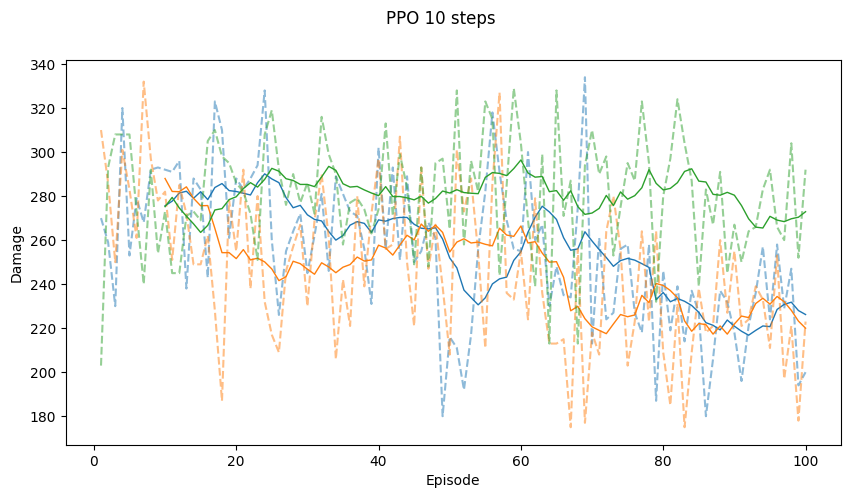

In [4]:
plot_rl_training(*[f + "ppo_10steps" for f in folders], suptitle="PPO 10 steps")

In [5]:
# plot_rl_training(*[f + "ppo_rs" for f in folders], suptitle="PPO Reward Shaping")

In [6]:
# plot_rl_training(*[f + "ppo_rs4" for f in folders], suptitle="PPO Strong Reward Shaping")

In [7]:
# plot_rl_training(*[f + "ppo_10steps_rs" for f in folders], suptitle="PPO 10 steps, Reward Shaping")

In [8]:
# plot_rl_training(*[f + "ppo_10steps_rs4" for f in folders], suptitle="PPO 10 steps, Strong Reward Shaping")

In [9]:
# plot_rl_training(*[f + "ppo_rs5" for f in folders], suptitle="PPO Reward Shaping TL")

../03rl1/logs/no_battery/ppo_10steps_rs5 100 files found
Average damage of last 10 episodes: 151.9
../03rl2/logs/no_battery/ppo_10steps_rs5 100 files found
Average damage of last 10 episodes: 188.0
../03rl3/logs/no_battery/ppo_10steps_rs5 100 files found
Average damage of last 10 episodes: 173.0


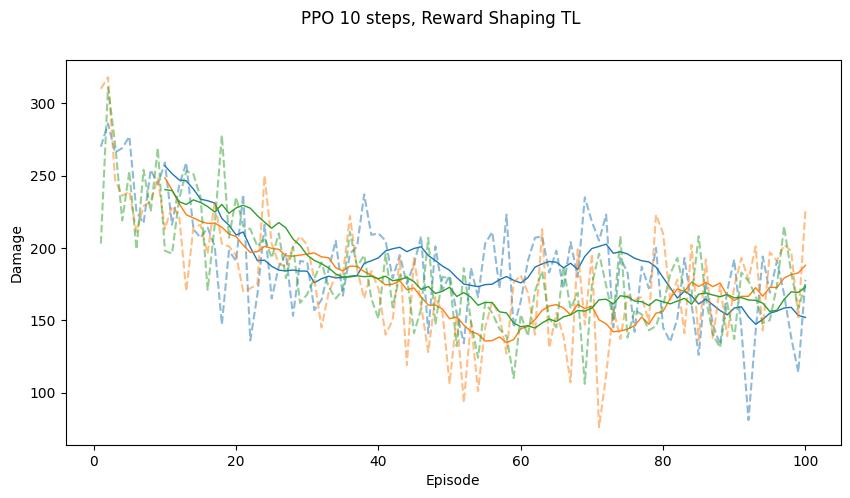

In [10]:
plot_rl_training(*[f + "ppo_10steps_rs5" for f in folders], suptitle="PPO 10 steps, Reward Shaping TL")

In [11]:
summary = pd.DataFrame(columns=["rl", "run", "damage"])

In [12]:
for folder in folders:
    for file in Path(folder).glob("*.csv"):
        data = pd.read_csv(file)
        damage = data.iloc[-10:]["damage"].mean()

        summary.loc[len(summary)] = [file.stem, folder, damage]
summary

,rl,run,damage
0,ppo_10steps,../03rl1/logs/no_battery/,226.2
1,ppo_10steps_rs5,../03rl1/logs/no_battery/,151.9
2,q_network_10steps,../03rl1/logs/no_battery/,196.2
3,q_network_10steps_rs5,../03rl1/logs/no_battery/,104.0
4,ppo_10steps,../03rl2/logs/no_battery/,220.0
5,ppo_10steps_rs5,../03rl2/logs/no_battery/,188.0
6,q_network_10steps,../03rl2/logs/no_battery/,190.7
7,q_network_10steps_rs5,../03rl2/logs/no_battery/,127.2
8,ppo_10steps,../03rl3/logs/no_battery/,272.9
9,ppo_10steps_rs5,../03rl3/logs/no_battery/,173.0


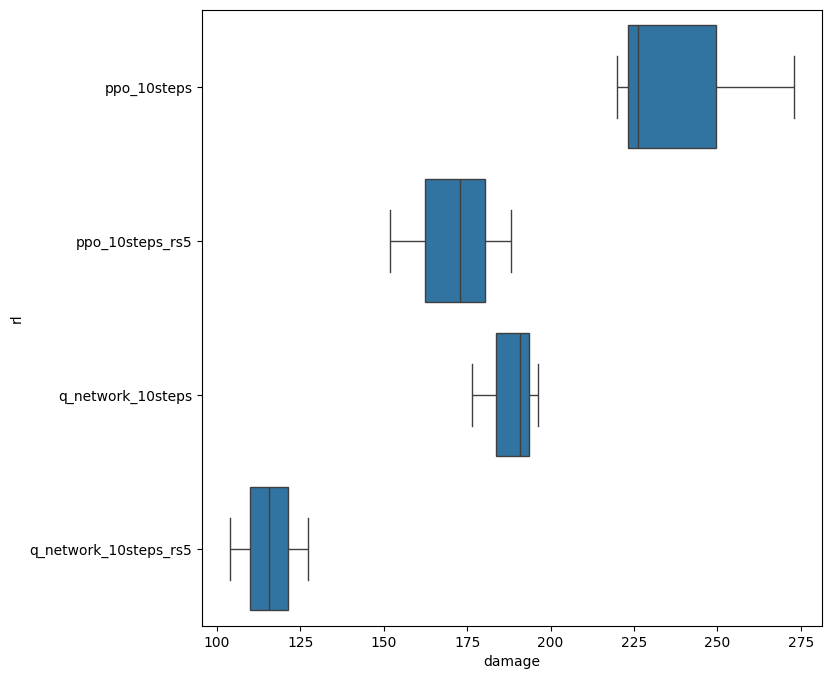

In [13]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.boxplot(x="damage", y="rl", data=summary, ax=ax)
plt.show()